# Online inverse optimization
Replay a dataset chronologically, update the model once per observation, and inspect the parameter and regret histories.

In [1]:
%matplotlib inline
import invoptlab as io


In [2]:
problem, dataset, theta_true = io.random_choice_experiment(
    observations=24, alternatives=6, seed=44,
    noise_model=io.BoltzmannNoise(temperature=0.15),
)
base = io.ProjectedSubgradientEstimator(
    loss=io.AugmentedSuboptimalityLoss(), learning_rate=0.3, regularization=1e-4
)
online = io.OnlineEstimator(base)
result = io.ExperimentRunner(io.ExperimentConfig(name='online-asl', geometry_samples=700)).run(
    problem, dataset.chronological(), online
)
result.metrics


{'observed_decision_accuracy': 0.9166666666666666,
 'mean_observed_decision_distance': 0.20833333333333334,
 'mean_surrogate_suboptimality': 0.02172174875811318,
 'max_surrogate_suboptimality': 0.47626907207388214,
 'clean_decision_accuracy': 0.9583333333333334,
 'mean_clean_decision_distance': 0.08333333333333333,
 'mean_true_regret': 0.0022185606833021545,
 'cumulative_true_regret': 0.05324545639925171,
 'max_true_regret': 0.05324545639925171,
 'true_regret_cvar_20': 0.010649091279850342,
 'parameter_angular_error': 0.12573298048280615,
 'parameter_cosine_similarity': 0.9921060165570015,
 'parameter_l1_error_normalized': 0.16134942007118908,
 'parameter_l2_error_normalized': 0.12565017662541203,
 'parameter_linf_error_normalized': 0.11789801729961075,
 'parameter_sign_accuracy': 1.0,
 'constraint_count': 120.0,
 'constraint_violation_rate': 0.016666666666666666,
 'mean_constraint_violation': 0.004344349751622634,
 'max_constraint_violation': 0.47626907207388197,
 'minimum_margin': -0

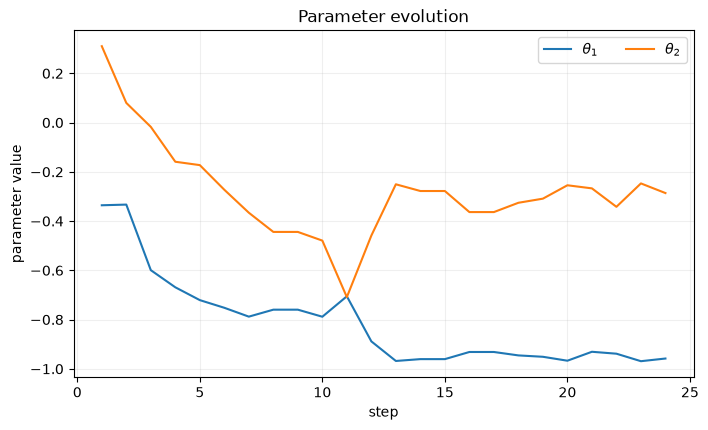

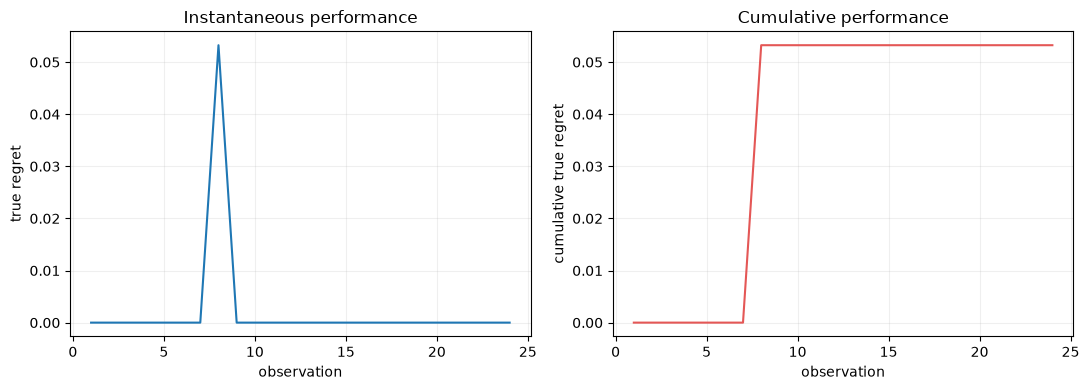

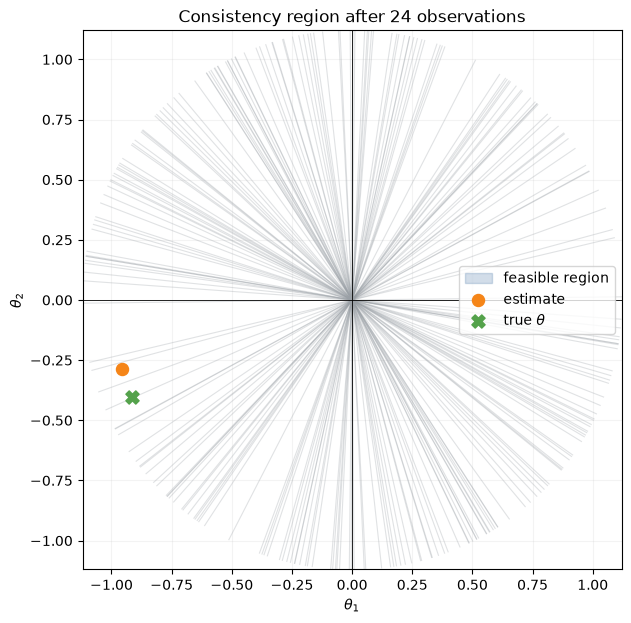

In [3]:
result.plot_parameters();
result.plot_regret();
result.plot_cone(problem, true_theta=theta_true);
